#**JouleAI G9-LATAM-Team-42**
##EnergiAI es un asesor energético automático diseñado para hogares y pequeños negocios. A través de inteligencia artificial, analiza el perfil de consumo eléctrico de los usuarios para clasificar su eficiencia, estimar su gasto mensual y ofrecer recomendaciones personalizadas y accionables de ahorro.

##El proyecto es desarrollado como parte de la simulación laboral de No Country por el equipo G9-LATAM-Team-42.

##**Introducción y Objetivos**

Desarrollar un modelo de Machine Learning capaz de clasificar el perfil de consumo energético (Eficiente, Moderado, Ineficiente), estimar la probabilidad, calcular el costo estimado a la tarifa de R$ 0,75/kWh e inferir recomendaciones personalizadas.


- Miembro 1: Carga/Simulación de datos, EDA, Preprocesamiento y Feature Engineering.  

- Miembro 2: Modelado ML, Métricas de Evaluación, Lógica de Recomendaciones, Estimación Financiera y Serialización (.pkl).

- Miembro 3: Integración Backend (Java / Spring Boot) y consumo del modelo / API REST (POST /analise-energetica).  

- Miembro 4: Configuración e Integración con Cloud Services (OCI - Object Storage / VM Deployment).

##**Generación y Carga de Datos**

### 1.1 Importación de Librerías Base
Carga de librerías esenciales para manipulación de datos, análisis numérico y visualización (pandas, numpy, scipy.stats, matplotlib, seaborn).

In [68]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import poisson, uniform, norm, ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
#Para visual se podria usar y evita que pandas oculte columnas al imprimir tablas
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###1.2 Generación / Conexión del Dataset Simulado

- Definición de semilla de reproducibilidad (seed = 42).  
- Simulación del dataset sintético representando consumos de residencias y pequeños negocios.
- Inclusión de variables requeridas por la API: consumo_kwh, uso_horario_pico, cantidad_equipos, tipo_inmueble y horas_alto_consumo.
- Modelado causal del target para definir los rangos de eficiencia energética (Eficiente, Moderado, Ineficiente).

In [71]:
#La ruta la cambian en sus respectivas PC OJOOOOOOOOO
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset_energia_viviendas.csv")

In [72]:
df.head()

,id_usuario,tipo_inmueble,personas_vivienda,antiguedad_inmueble,cantidad_equipos,tiene_aire_acondicionado,tiene_calentador_electrico,electrodomesticos_eficientes,uso_horario_pico,horas_alto_consumo,consumo_kwh,consumo_promedio_diario,ratio_persona_kwh,categoria_eficiencia
0,U0000,Casa,4,8,4,0,0,0,0,0.4,423,14.1,105.8,Moderado
1,U0001,Oficina,3,21,7,0,0,0,1,4.7,821,27.4,273.7,Ineficiente
2,U0002,Apartamento,3,16,7,1,0,1,0,5.8,516,17.2,172.0,Moderado
3,U0003,Apartamento,2,13,9,0,0,1,1,19.7,526,17.5,263.0,Ineficiente
4,U0004,Casa,1,15,8,1,0,0,0,17.0,514,17.1,514.0,Ineficiente


In [73]:
df.tail()

,id_usuario,tipo_inmueble,personas_vivienda,antiguedad_inmueble,cantidad_equipos,tiene_aire_acondicionado,tiene_calentador_electrico,electrodomesticos_eficientes,uso_horario_pico,horas_alto_consumo,consumo_kwh,consumo_promedio_diario,ratio_persona_kwh,categoria_eficiencia
4995,U4995,Comercio,9,24,7,1,0,1,0,15.1,1734,57.8,192.7,Moderado
4996,U4996,Casa,4,18,10,0,0,0,1,17.5,839,28.0,209.8,Ineficiente
4997,U4997,Casa,2,17,7,0,0,0,0,16.5,457,15.2,228.5,Ineficiente
4998,U4998,Comercio,5,10,4,0,0,0,0,20.4,784,26.1,156.8,Moderado
4999,U4999,Apartamento,1,15,9,0,0,0,1,21.7,383,12.8,383.0,Ineficiente


##**Transformación y Preprocesamiento de Datos**

###2.1 Comprobación de Nulos y Inconsistencias

####Inspección de la estructura de datos (df.info(), df.describe()).


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_usuario                    5000 non-null   object 
 1   tipo_inmueble                 5000 non-null   object 
 2   personas_vivienda             5000 non-null   int64  
 3   antiguedad_inmueble           5000 non-null   int64  
 4   cantidad_equipos              5000 non-null   int64  
 5   tiene_aire_acondicionado      5000 non-null   int64  
 6   tiene_calentador_electrico    5000 non-null   int64  
 7   electrodomesticos_eficientes  5000 non-null   int64  
 8   uso_horario_pico              5000 non-null   int64  
 9   horas_alto_consumo            5000 non-null   float64
 10  consumo_kwh                   5000 non-null   int64  
 11  consumo_promedio_diario       5000 non-null   float64
 12  ratio_persona_kwh             5000 non-null   float64
 13  cat

In [75]:
df.describe()

,personas_vivienda,antiguedad_inmueble,cantidad_equipos,tiene_aire_acondicionado,tiene_calentador_electrico,electrodomesticos_eficientes,uso_horario_pico,horas_alto_consumo,consumo_kwh,consumo_promedio_diario,ratio_persona_kwh
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3.070800,14.853600,8.025400,0.39380,0.289200,0.250800,0.356800,11.944080,805.779800,26.859600,328.532300
std,1.673424,3.771023,2.786164,0.48864,0.453436,0.433517,0.479103,6.960342,356.056369,11.869305,210.049297
min,1.000000,2.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,50.000000,1.700000,10.000000
25%,2.000000,12.000000,6.000000,0.00000,0.000000,0.000000,0.000000,5.800000,545.750000,18.200000,186.650000
50%,3.000000,15.000000,8.000000,0.00000,0.000000,0.000000,0.000000,12.100000,750.000000,25.000000,268.900000
75%,4.000000,17.000000,10.000000,1.00000,1.000000,1.000000,1.000000,17.900000,1014.000000,33.800000,403.625000
max,10.000000,31.000000,20.000000,1.00000,1.000000,1.000000,1.000000,24.000000,2000.000000,66.700000,2000.000000


####Verificación y validación de valores ausentes (nulos) y duplicados.

In [76]:
#Para ver los nulos que hay en cada columna
print("Valores nulos x variable:")
print(df.isnull().sum())

Valores nulos x variable:
id_usuario                      0
tipo_inmueble                   0
personas_vivienda               0
antiguedad_inmueble             0
cantidad_equipos                0
tiene_aire_acondicionado        0
tiene_calentador_electrico      0
electrodomesticos_eficientes    0
uso_horario_pico                0
horas_alto_consumo              0
consumo_kwh                     0
consumo_promedio_diario         0
ratio_persona_kwh               0
categoria_eficiencia            0
dtype: int64


In [77]:
#Todo nitido
print(f"\nCantidad de filas duplicadas: {df.duplicated().sum()}")
print(f"Los ids duplicados: {df['id_usuario'].duplicated().sum()}")


Cantidad de filas duplicadas: 0
Los ids duplicados: 0


###2.2 Limpieza y Tratamiento

####Identificación y tratamiento de valores atípicos (outliers) en las variables numéricas continuas (consumo_kwh, horas_alto_consumo).

In [78]:
#Es para calculan el primer y tercer cuartil
#siendo para ver los limites estadisticos

def detectar_outliers_iqr(serie, k=1.5):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf, limite_sup = Q1 - k * IQR, Q3 + k * IQR
    return (serie < limite_inf) | (serie > limite_sup), limite_inf, limite_sup

variables_continuas = ["consumo_kwh", "horas_alto_consumo","consumo_promedio_diario", "ratio_persona_kwh"]

for var in variables_continuas:
    outliers_mask, li, ls = detectar_outliers_iqr(df[var])
    print(f"{var}: {outliers_mask.sum()} outliers "f"(limites: [{li:.1f}, {ls:.1f}])")

consumo_kwh: 103 outliers (limites: [-156.6, 1716.4])
horas_alto_consumo: 0 outliers (limites: [-12.3, 36.0])
consumo_promedio_diario: 103 outliers (limites: [-5.2, 57.2])
ratio_persona_kwh: 273 outliers (limites: [-138.8, 729.1])


####Filtrado de incongruencias lógicas (ej. horas diarias de alto consumo > 24).

In [79]:
#Para ver si hay valores que No cumplen reglas logicas (por ejemplo horas negativas)
inconsistencias = {
    "horas_alto_consumo fuera de [0,24]": ((df["horas_alto_consumo"] < 0) |(df["horas_alto_consumo"] > 24)).sum(),
    "consumo_kwh <= 0":                   (df["consumo_kwh"] <= 0).sum(),
    "personas_vivienda fuera de [1,10]":  ((df["personas_vivienda"] < 1) |(df["personas_vivienda"] > 10)).sum(),
    "antiguedad_inmueble fuera de [0,50]": ((df["antiguedad_inmueble"] < 0) |(df["antiguedad_inmueble"] > 50)).sum(),}

#lo pasamos a serie
pd.Series(inconsistencias, name="cantidad_de_casos")

,cantidad_de_casos
"horas_alto_consumo fuera de [0,24]",0
consumo_kwh <= 0,0
"personas_vivienda fuera de [1,10]",0
"antiguedad_inmueble fuera de [0,50]",0


In [80]:
#Se recortan las horas_alto_consumo al rango válido [0, 24]
df["horas_alto_consumo"] = df["horas_alto_consumo"].clip(0, 24)

In [81]:
#Si el consumo es 0 o negativo la fila entera no tiene sentido, por lo que la eliminamos
#Y de paso se reindexa
df = df[df["consumo_kwh"] > 0].reset_index(drop=True)

print(f"\nRegistros tras limpieza: {df.shape[0]}")


Registros tras limpieza: 5000


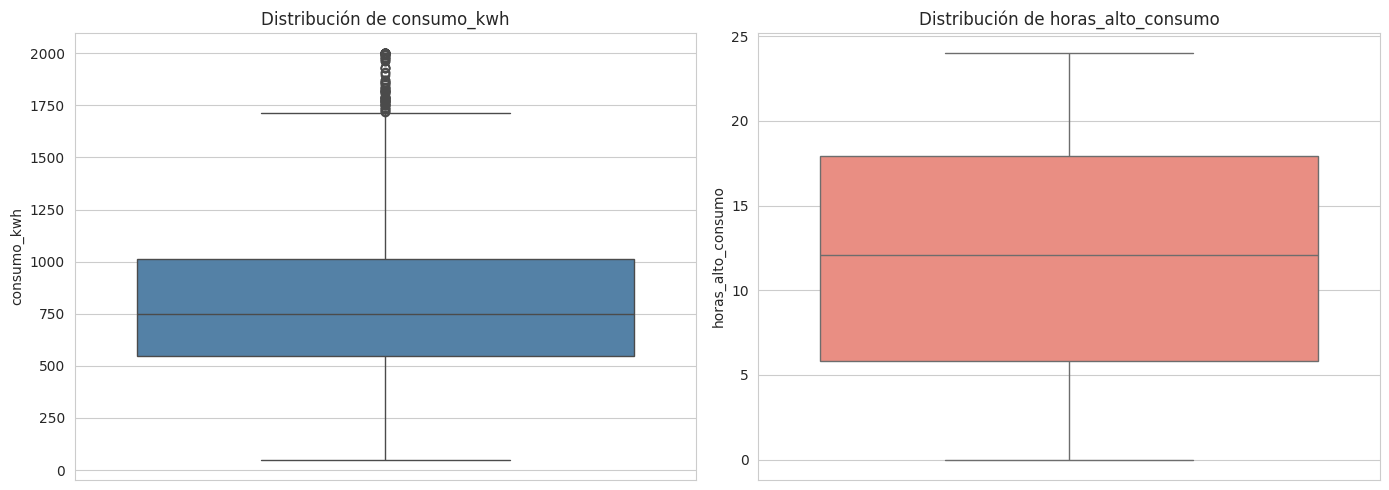

In [82]:
#Ver los outliers de cada variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df["consumo_kwh"], ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de consumo_kwh")

sns.boxplot(y=df["horas_alto_consumo"], ax=axes[1], color="salmon")
axes[1].set_title("Distribución de horas_alto_consumo")
plt.tight_layout()
plt.show()

###2.3 Estandarización de Tipos de Datos

####Conversión de variables booleanas (uso_horario_pico) a formato binario/lógico.

####Ajuste de variables categóricas (tipo_inmueble) y escalado numérico según corresponda.

In [83]:
#Ver si estan guardadas como enteros
variables_binarias = ["uso_horario_pico", "tiene_aire_acondicionado","tiene_calentador_electrico", "electrodomesticos_eficientes"]
for var in variables_binarias:
    df[var] = df[var].astype(int)

In [84]:
df["tipo_inmueble"] = df["tipo_inmueble"].astype("category")
df["categoria_eficiencia"] = pd.Categorical(df["categoria_eficiencia"],categories=["Eficiente", "Moderado", "Ineficiente"],ordered=True)

In [85]:
variables_float = ["consumo_kwh", "horas_alto_consumo","consumo_promedio_diario", "ratio_persona_kwh"]
df[variables_float] = df[variables_float].astype(float)

variables_int = ["personas_vivienda", "antiguedad_inmueble", "cantidad_equipos"]
df[variables_int] = df[variables_int].astype(int)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   id_usuario                    5000 non-null   object  
 1   tipo_inmueble                 5000 non-null   category
 2   personas_vivienda             5000 non-null   int64   
 3   antiguedad_inmueble           5000 non-null   int64   
 4   cantidad_equipos              5000 non-null   int64   
 5   tiene_aire_acondicionado      5000 non-null   int64   
 6   tiene_calentador_electrico    5000 non-null   int64   
 7   electrodomesticos_eficientes  5000 non-null   int64   
 8   uso_horario_pico              5000 non-null   int64   
 9   horas_alto_consumo            5000 non-null   float64 
 10  consumo_kwh                   5000 non-null   float64 
 11  consumo_promedio_diario       5000 non-null   float64 
 12  ratio_persona_kwh             5000 non-null   fl

In [87]:
df.head()

,id_usuario,tipo_inmueble,personas_vivienda,antiguedad_inmueble,cantidad_equipos,tiene_aire_acondicionado,tiene_calentador_electrico,electrodomesticos_eficientes,uso_horario_pico,horas_alto_consumo,consumo_kwh,consumo_promedio_diario,ratio_persona_kwh,categoria_eficiencia
0,U0000,Casa,4,8,4,0,0,0,0,0.4,423.0,14.1,105.8,Moderado
1,U0001,Oficina,3,21,7,0,0,0,1,4.7,821.0,27.4,273.7,Ineficiente
2,U0002,Apartamento,3,16,7,1,0,1,0,5.8,516.0,17.2,172.0,Moderado
3,U0003,Apartamento,2,13,9,0,0,1,1,19.7,526.0,17.5,263.0,Ineficiente
4,U0004,Casa,1,15,8,1,0,0,0,17.0,514.0,17.1,514.0,Ineficiente


In [88]:
print(df.dtypes)

id_usuario                        object
tipo_inmueble                   category
personas_vivienda                  int64
antiguedad_inmueble                int64
cantidad_equipos                   int64
tiene_aire_acondicionado           int64
tiene_calentador_electrico         int64
electrodomesticos_eficientes       int64
uso_horario_pico                   int64
horas_alto_consumo               float64
consumo_kwh                      float64
consumo_promedio_diario          float64
ratio_persona_kwh                float64
categoria_eficiencia            category
dtype: object


##**Análisis Exploratorio de Datos (EDA)**  **-andriuu**

###3.1 Análisis Univariado

####Análisis de distribución de las variables clave: consumo_kwh, cantidad_equipos y horas_alto_consumo.  

####Visualización del balanceo de clases de la variable objetivo (categoria / perfil energético).

###3.2 Análisis Bivariado y MultivariadoRelación entre el tipo_inmueble y el consumo_kwh promedio.

####Impacto de uso_horario_pico y horas_alto_consumo sobre la categorización de eficiencia.

####Matriz de correlación entre variables numéricas.

###3.3 Creación de Variables Derivadas (Feature Engineering)

- Cálculo del consumo estimado por equipo consumo_kwh/cantidad_equipos.
- Indicador de intensidad de uso horario (horas_alto_consumo/24).

## **4. Preprocesamiento Avanzado para Machine Learning**  **-andriuu**

### **4.1 Codificación de Variables Categóricas**
Aplicación de One-Hot Encoding / Ordinal Encoding para la variable tipo_inmueble ("Casa", "Apartamento", "Comercio", etc.).  

### **4.2 Escalado de Características**
Normalización o estandarización (StandardScaler / RobustScaler) de variables numéricas continuas para preparar el conjunto de datos de entrenamiento.

### **4.3 División del Dataset (Train / Test Split)**
Separación del dataset en conjunto de entrenamiento ($80\%$) y prueba ($20\%$) manteniendo estratificación respecto a la variable objetivo (categoria).  

## **5. Modelado de Machine Learning (Supervisado)**  **-Karen**

### **5.1 Entrenamiento del Modelo Principal (Random Forest)**
Instanciación y entrenamiento del algoritmo Random Forest Classifier como modelo principal de clasificación de perfil energético (Eficiente, Moderado, Ineficiente).

### **5.2 Optimización de Hiperparámetros**
Ajuste fino de parámetros (n_estimators, max_depth, min_samples_split) mediante GridSearchCV o RandomizedSearchCV para evitar el sobreajuste (overfitting)

## **6. Evaluación de Modelos e Interpretabilidad**  **-Karen**

### **6.1 Métricas de Rendimiento**

- Cálculo de Accuracy, Precision, Recall y F1-Score ponderado por clase.
- Matriz de confusión para validar falsos positivos y falsos negativos en la clasificación de perfiles

### **6.2 Extracción de Probabilidades y Feature Importance**
- Evaluación del método predict_proba() para obtener la certeza de la clasificación.  
- Gráfico de importancia de variables para interpretar las decisiones del modelo Random Forest.  

## **7. Módulo de Reglas de Negocio, Estimación Financiera y Recomendaciones**

### **7.1 Lógica de Cálculo Financiero**

Implementación de la fórmula de estimación de costo mensual aplicando la tarifa de referencia obligatoria costo_estimado_mensual = consumo_kwh*0.75.  

### **7.2 Motor de Recomendaciones de Optimización**

Desarrollo de un motor de reglas condicionales para generar recomendaciones dinámicas y personalizadas:  
- Si uso_horario_pico == True $\rightarrow$ "Reducir uso en horarios de pico".  
- Si cantidad_equipos o horas_alto_consumo superan umbrales normativos $\rightarrow$ "Evaluar equipos de alto consumo".  
- Sugerencias de eficiencia según la categoría inferida (Eficiente, Moderado, Ineficiente).  

## 8. Simulación del Pipeline de Inferencia

### **8.1 Simulación de Entrada y Salida (Endpoint Simulation)**

- Construcción de la función analizar_consumo(payload) para emular el comportamiento del endpoint REST POST /analise-energetica.  
- Prueba integral utilizando el JSON de ejemplo provisto por el requerimiento:  
  - Input Test: {"consumo_kwh": 420, "uso_horario_pico": true, "cantidad_equipos": 10, "tipo_inmueble": "Casa", "horas_alto_consumo": 8}.  
  - Output Esperado: Estructura JSON con categoria, probabilidad, costo_estimado_mensual y recomendaciones

## **9. Serialización e Integración Cloud (OCI)**

### **9.1 Exportación del Modelo y Pipeline (.pkl)**
Exportación del modelo entrenado de Random Forest, encoders y scalers en formato binario (joblib / pickle).

### **9.2 Conexión y Subida a OCI (Oracle Cloud Infrastructure)**
- Configuración del SDK de OCI en Python (oci).
- Automatización del despliegue/subida del archivo .pkl hacia un bucket de OCI Object Storage para su consumo por la aplicación Java Spring Boot.